# 🚭 바이오마커 기반 흡연 여부 예측 모델

> **데이터**: Kaggle — *Smoker Status Prediction using Bio-Signals* (`playground-series-s3e24`)  
> **목표**: 혈액·신체 검사 수치(바이오마커)만으로 흡연 여부를 예측하고, 어떤 지표가 핵심인지 SHAP으로 해석한다  
> **방법**: EDA → 로지스틱 회귀 → Random Forest → SHAP 해석

---

## 📐 연구 설계

| 구분 | 내용 |
|---|---|
| **독립변수 (X)** | 27개 바이오마커 (신체측정, 혈압, 혈액검사, 간기능 등) |
| **종속변수 (y)** | 흡연 여부 (0=비흡연, 1=흡연) |
| **분석 방법** | 로지스틱 회귀(오즈비 해석) + Random Forest(성능) + SHAP(변수 설명) |
| **평가 지표** | AUC-ROC, F1-score, 5-Fold Cross Validation |

### 💡 연구 가설
- **H1**: GTP(γ-GTP), 헤모글로빈, 중성지방은 흡연자에서 유의미하게 높을 것이다
- **H2**: 혈액·신체 검사 수치만으로 흡연 여부를 AUC 0.80 이상으로 예측할 수 있다
- **H3**: Random Forest가 로지스틱 회귀보다 높은 예측 성능을 보일 것이다

## ⚙️ Cell 1 · 환경 설정 및 패키지 설치

In [1]:
!pip install -q shap
!apt-get install -y -q fonts-nanum
print("✅ 설치 완료")

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,939 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
✅ 설치 완료


## 📥 Cell 2 · Kaggle 데이터 다운로드

**방법 A** — `kaggle.json` 직접 업로드 (권장)  
1. [Kaggle 계정 설정](https://www.kaggle.com/settings) → *Create New Token* → `kaggle.json` 다운로드  
2. 아래 셀 실행  

**방법 B** — Google Drive에 `train.csv`가 있으면 두 번째 셀 주석 해제

In [3]:
# ── 방법 A: kaggle.json 업로드 ──────────────────────────────
from google.colab import files
uploaded = files.upload()   # kaggle.json 선택

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c playground-series-s3e24
!unzip -q playground-series-s3e24.zip

DATA_PATH = "train.csv"
print("✅ 데이터 다운로드 완료")

Saving kaggle.json to kaggle.json
100% 6.81M/6.81M [00:00<00:00, 81.4MB/s]

✅ 데이터 다운로드 완료


In [ ]:
# ── 방법 B: Google Drive ─────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/train.csv'

## 📦 Cell 3 · 라이브러리 임포트

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 (Colab 전용)
fe = fm.FontEntry(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({
    'font.family'       : 'NanumGothic',
    'axes.unicode_minus': False,
    'figure.dpi'        : 120
})
print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 🔍 Cell 4 · 데이터 로드 및 기본 확인

In [5]:
df = pd.read_csv(DATA_PATH)
if 'id' in df.columns:
    df = df.drop(columns=['id'])

print(f"데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열")
print(f"\n흡연 비율:")
print(df['smoking'].value_counts(normalize=True)
      .rename({0:'비흡연자(0)', 1:'흡연자(1)'})
      .map('{:.1%}'.format))
print(f"\n결측치 합계: {df.isnull().sum().sum()}개")
df.head()

데이터 크기: 159,256행 × 23열

흡연 비율:
smoking
비흡연자(0)    56.3%
흡연자(1)     43.7%
Name: proportion, dtype: object

결측치 합계: 0개


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,55,165,60,81.0,0.5,0.6,1,1,135,87,...,40,75,16.5,1,1.0,22,25,27,0,1
1,70,165,65,89.0,0.6,0.7,2,2,146,83,...,57,126,16.2,1,1.1,27,23,37,1,0
2,20,170,75,81.0,0.4,0.5,1,1,118,75,...,45,93,17.4,1,0.8,27,31,53,0,1
3,35,180,95,105.0,1.5,1.2,1,1,131,88,...,38,102,15.9,1,1.0,20,27,30,1,0
4,30,165,60,80.5,1.5,1.0,1,1,121,76,...,44,93,15.4,1,0.8,19,13,17,0,1


## 🗂️ Cell 5 · 변수 설계

| 그룹 | 변수 | 가설 |
|---|---|---|
| 신체측정 | age, height, weight, waist | 흡연자에서 허리둘레↑ |
| 혈압 | systolic, relaxation | 흡연 → 혈압 상승 |
| 혈액검사 | cholesterol, triglyceride, HDL, LDL, hemoglobin | 흡연 → 지질 이상, 헤모글로빈↑ |
| **간기능** | AST, ALT, **Gtp** | **GTP가 핵심 예측 변수일 것** |
| 기타 | urine protein, creatinine, dental caries | 충치 유병률 흡연자에서↑ |

In [6]:
GROUPS = {
    '신체측정': ['age', 'height(cm)', 'weight(kg)', 'waist(cm)'],
    '시력/청력': ['eyesight(left)', 'eyesight(right)',
                  'hearing(left)', 'hearing(right)'],
    '혈압':     ['systolic', 'relaxation'],
    '혈액검사': ['fasting blood sugar', 'cholesterol', 'triglyceride',
                 'HDL', 'LDL', 'hemoglobin'],
    '간기능':   ['AST', 'ALT', 'Gtp'],
    '기타':     ['urine protein', 'serum creatinine', 'dental caries'],
}

FEATURE_COLS = [col for cols in GROUPS.values() for col in cols]
TARGET_COL   = 'smoking'

print("독립변수 구성:")
for g, cols in GROUPS.items():
    print(f"  [{g}]  {', '.join(cols)}")
print(f"\n총 {len(FEATURE_COLS)}개 변수")

독립변수 구성:
  [신체측정]  age, height(cm), weight(kg), waist(cm)
  [시력/청력]  eyesight(left), eyesight(right), hearing(left), hearing(right)
  [혈압]  systolic, relaxation
  [혈액검사]  fasting blood sugar, cholesterol, triglyceride, HDL, LDL, hemoglobin
  [간기능]  AST, ALT, Gtp
  [기타]  urine protein, serum creatinine, dental caries

총 22개 변수


## 🔧 Cell 6 · 전처리 — 이상치 Winsorizing + Train/Test 분할

In [9]:
TARGET_COL = 'smoking'

GROUPS = {
    '신체':   ['age', 'height(cm)', 'weight(kg)', 'waist(cm)'],
    '시력청력': ['eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)'],
    '혈압':   ['systolic', 'relaxation'],
    '혈당지질': ['fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL'],
    '혈액검사': ['hemoglobin', 'Urine protein', 'serum creatinine'],
    '간기능':  ['AST', 'ALT', 'Gtp'],
    '기타':   ['dental caries'],
}

FEATURE_COLS = [c for c in df.columns if c != TARGET_COL]

# 검증
all_group_cols = sum(GROUPS.values(), [])
missing = [c for c in all_group_cols if c not in df.columns]
print("누락 컬럼:", missing if missing else "없음 ✅")

누락 컬럼: 없음 ✅


In [10]:
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL]

# 이상치: 상하위 1% Winsorizing (혈액·간기능·혈압만)
winsor_cols = GROUPS['혈액검사'] + GROUPS['간기능'] + GROUPS['혈압']
for col in winsor_cols:
    lo, hi = X[col].quantile(0.01), X[col].quantile(0.99)
    X[col] = X[col].clip(lo, hi)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Train 흡연율: {y_train.mean():.3f}  |  Test 흡연율: {y_test.mean():.3f}")

Train: 127,404  |  Test: 31,852
Train 흡연율: 0.437  |  Test 흡연율: 0.437


## 📊 Cell 7 · EDA — 집단 간 바이오마커 분포 비교

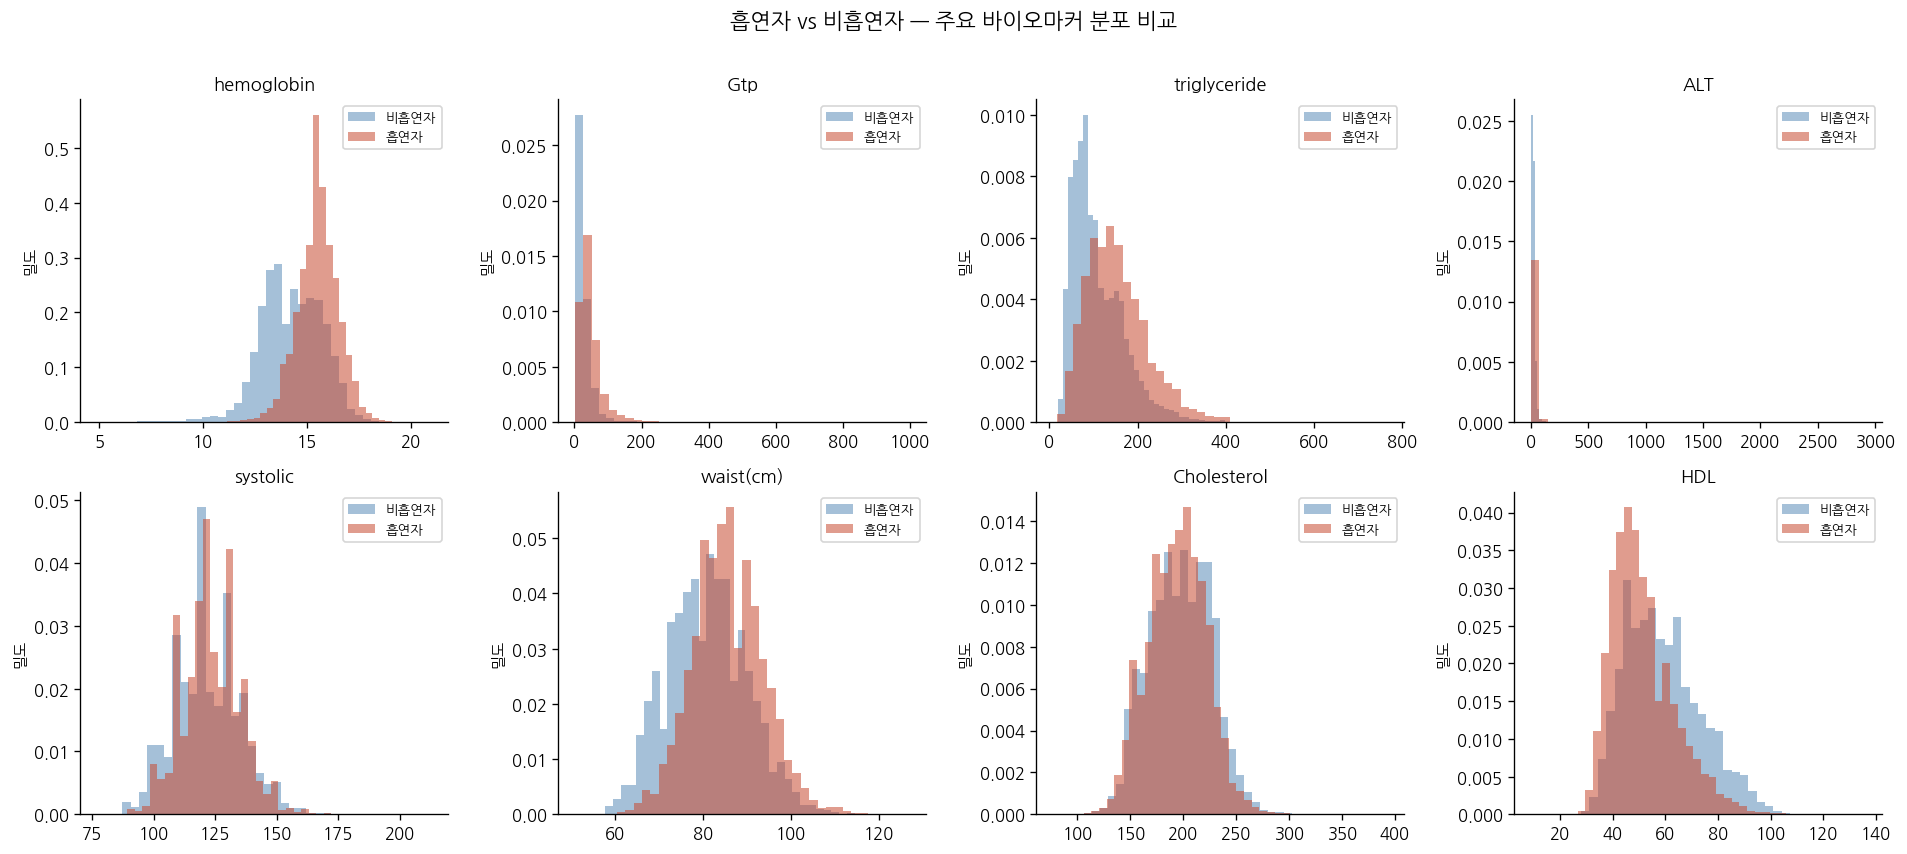

In [12]:
key_vars = ['hemoglobin', 'Gtp', 'triglyceride', 'ALT',
            'systolic', 'waist(cm)', 'Cholesterol', 'HDL']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette   = {0: '#5B8DB8', 1: '#C84B31'}
label_map = {0: '비흡연자', 1: '흡연자'}

for i, var in enumerate(key_vars):
    ax = axes[i]
    for s, color in palette.items():
        data = df[df[TARGET_COL] == s][var].dropna()
        ax.hist(data, bins=40, alpha=0.55, color=color,
                label=label_map[s], density=True)
    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_ylabel('밀도', fontsize=9)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('흡연자 vs 비흡연자 — 주요 바이오마커 분포 비교',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_biomarker.png', bbox_inches='tight')
plt.show()

In [13]:
# 집단 평균 비교표
mean_tbl = df.groupby(TARGET_COL)[key_vars].mean().T.rename(
    columns={0: '비흡연자', 1: '흡연자'})
mean_tbl['차이(흡연-비흡연)'] = (mean_tbl['흡연자'] - mean_tbl['비흡연자']).round(2)
mean_tbl['차이(%)'] = ((mean_tbl['흡연자'] - mean_tbl['비흡연자'])
                       / mean_tbl['비흡연자'] * 100).round(1)
mean_tbl.round(2)

smoking,비흡연자,흡연자,차이(흡연-비흡연),차이(%)
hemoglobin,14.23,15.53,1.30,9.1
Gtp,27.81,47.03,19.22,69.1
triglyceride,108.24,152.54,44.29,40.9
ALT,24.00,29.83,5.83,24.3
systolic,121.85,123.35,1.50,1.2
waist(cm),80.93,85.67,4.74,5.9
Cholesterol,197.10,194.12,-2.97,-1.5
HDL,59.19,51.56,-7.63,-12.9


## 🗺️ Cell 8 · EDA — 상관관계 히트맵

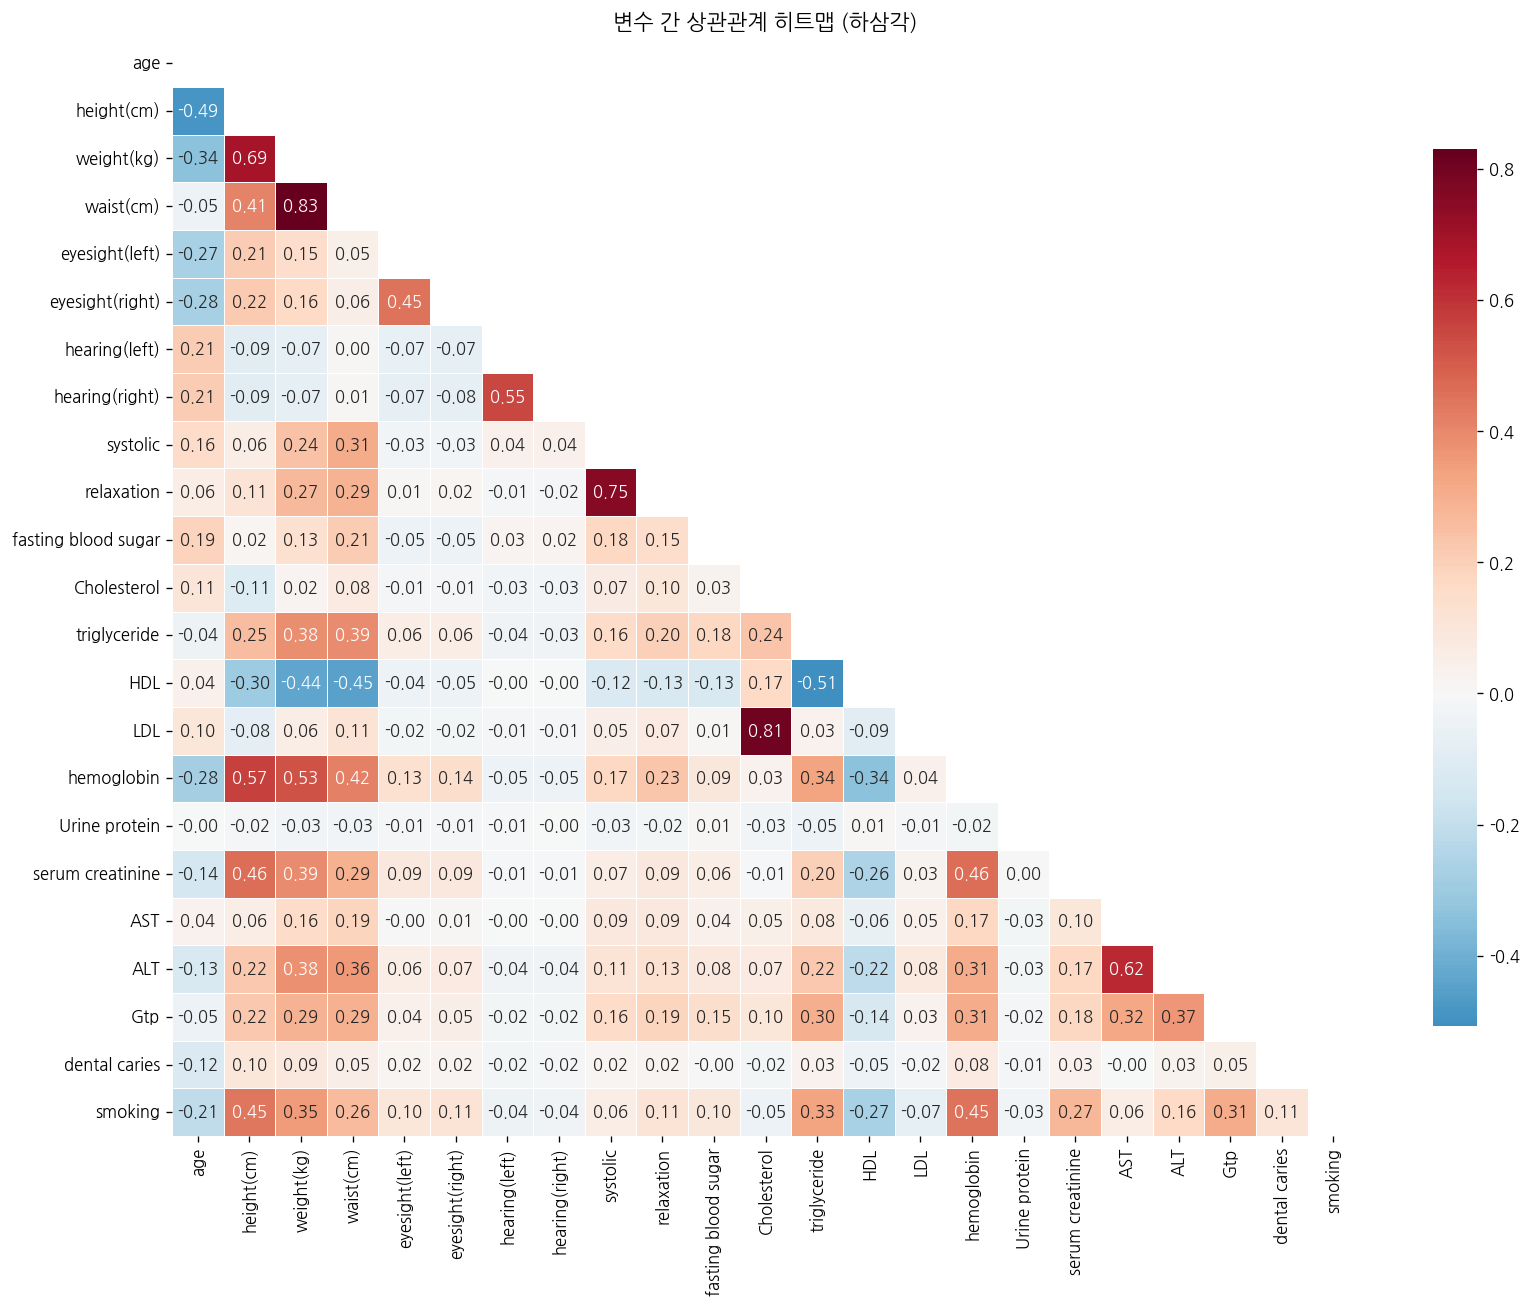

In [14]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = df[FEATURE_COLS + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.3,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('변수 간 상관관계 히트맵 (하삼각)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight')
plt.show()

## 📈 Cell 9 · 모델 1 — 로지스틱 회귀 + 오즈비

In [15]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42, C=1.0))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)

print(f"로지스틱 회귀  AUC: {auc_lr:.4f}\n")
print(classification_report(y_test, y_pred_lr, target_names=['비흡연자', '흡연자']))

로지스틱 회귀  AUC: 0.8315

              precision    recall  f1-score   support

        비흡연자       0.79      0.76      0.77     17921
         흡연자       0.70      0.73      0.72     13931

    accuracy                           0.75     31852
   macro avg       0.74      0.75      0.74     31852
weighted avg       0.75      0.75      0.75     31852



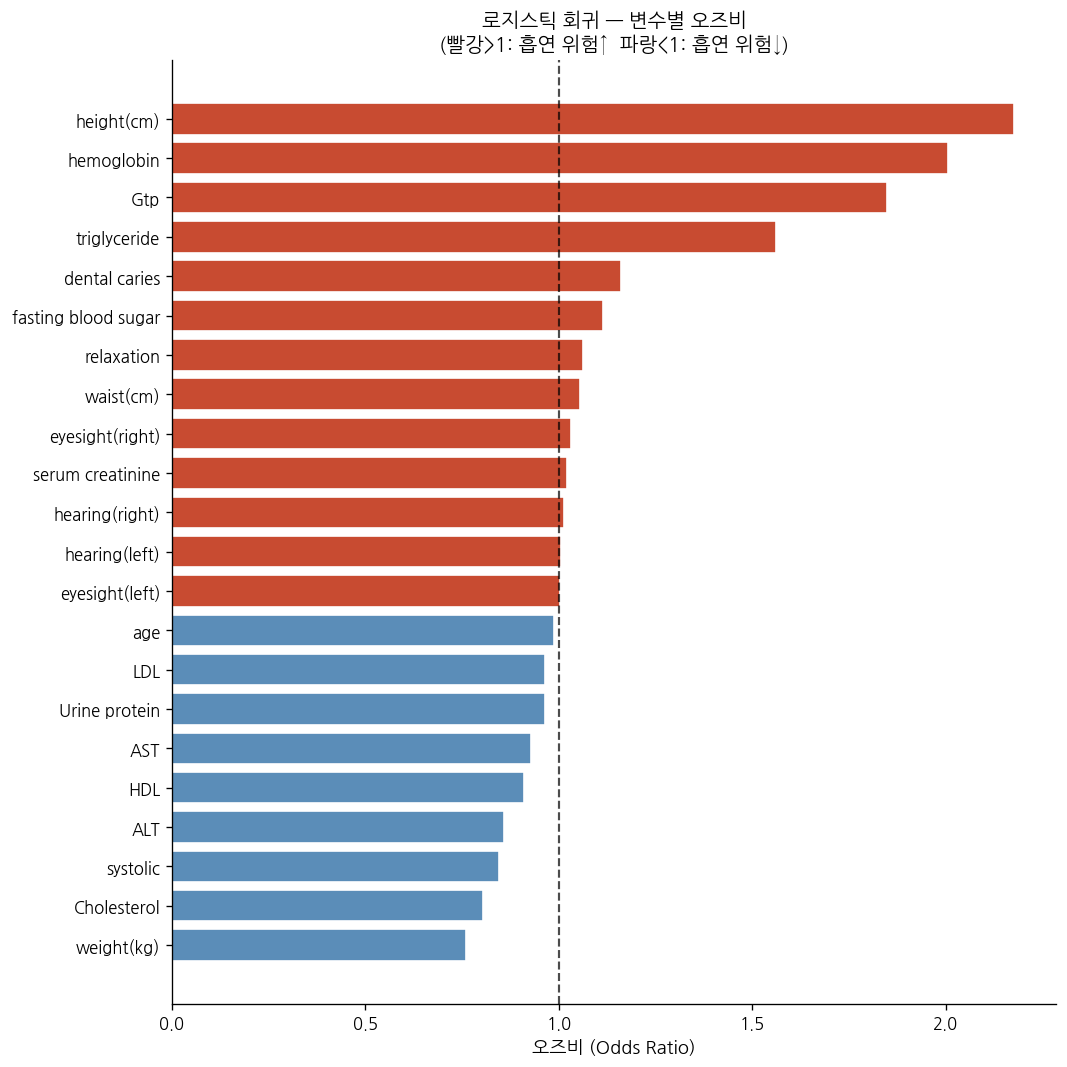

In [16]:
coef  = lr_pipe.named_steps['model'].coef_[0]
or_df = pd.DataFrame({'변수': FEATURE_COLS, '오즈비': np.exp(coef)
                      }).sort_values('오즈비', ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
colors  = ['#C84B31' if v > 1 else '#5B8DB8' for v in or_df['오즈비']]
ax.barh(or_df['변수'], or_df['오즈비'], color=colors, edgecolor='white')
ax.axvline(x=1, color='black', lw=1.3, linestyle='--', alpha=0.7)
ax.set_xlabel('오즈비 (Odds Ratio)', fontsize=11)
ax.set_title('로지스틱 회귀 — 변수별 오즈비\n(빨강>1: 흡연 위험↑  파랑<1: 흡연 위험↓)',
             fontsize=12, fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('lr_odds_ratio.png', bbox_inches='tight')
plt.show()

## 🌲 Cell 10 · 모델 2 — Random Forest

In [17]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=20,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest  AUC: {auc_rf:.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=['비흡연자', '흡연자']))

Random Forest  AUC: 0.8520

              precision    recall  f1-score   support

        비흡연자       0.85      0.72      0.78     17921
         흡연자       0.70      0.83      0.76     13931

    accuracy                           0.77     31852
   macro avg       0.77      0.78      0.77     31852
weighted avg       0.78      0.77      0.77     31852



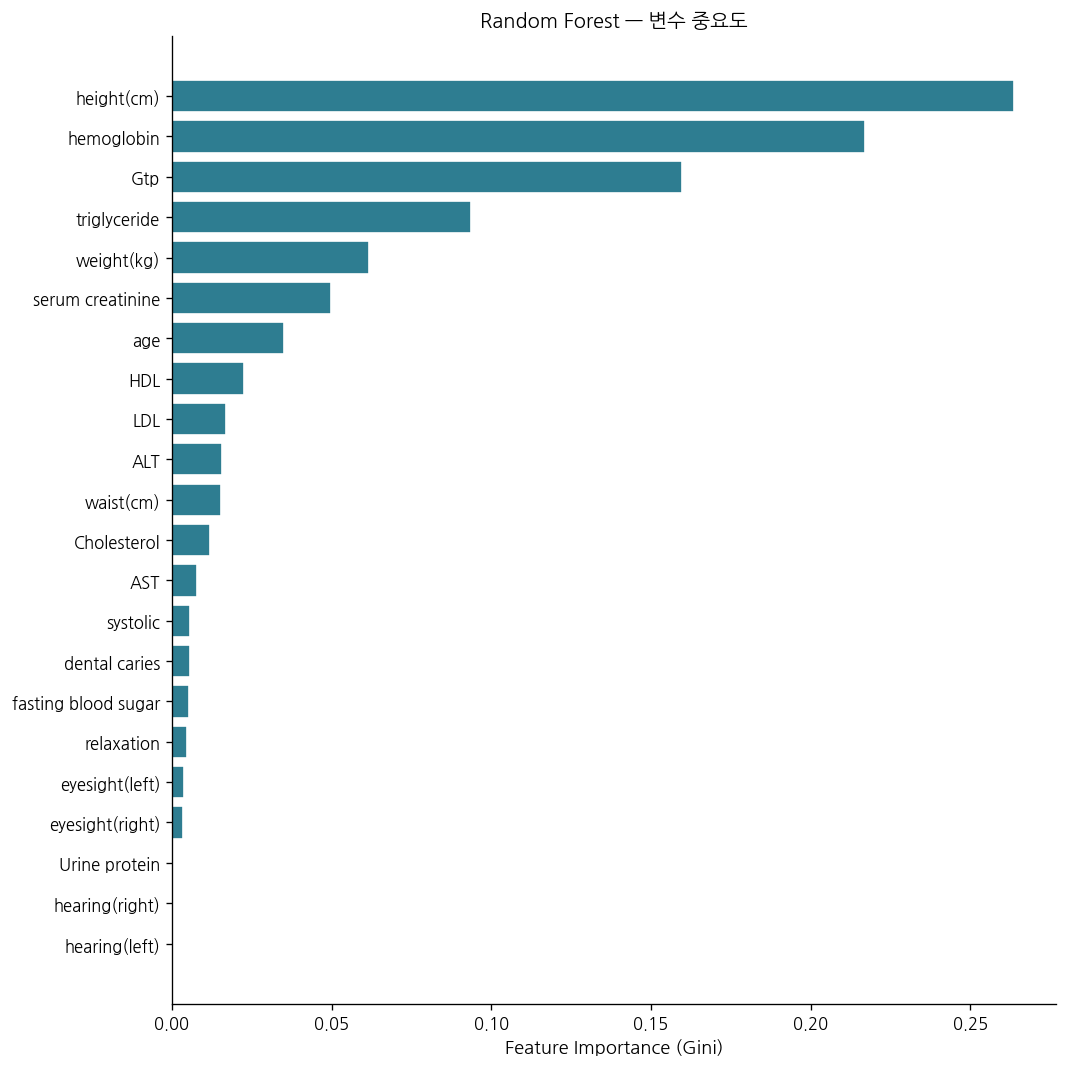

In [18]:
fi_df = pd.DataFrame({
    '변수': FEATURE_COLS, '중요도': rf.feature_importances_
}).sort_values('중요도', ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(fi_df['변수'], fi_df['중요도'], color='#2E7D91', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Random Forest — 변수 중요도', fontsize=12, fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', bbox_inches='tight')
plt.show()

Cell 10-B 추가 — LightGBM 모델

In [28]:
!pip install -q lightgbm
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         callbacks=[])

y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]
y_pred_lgbm = lgbm.predict(X_test)
auc_lgbm    = roc_auc_score(y_test, y_prob_lgbm)

print(f"LightGBM  AUC: {auc_lgbm:.4f}\n")
print(classification_report(y_test, y_pred_lgbm, target_names=['비흡연자', '흡연자']))

LightGBM  AUC: 0.8658

              precision    recall  f1-score   support

        비흡연자       0.84      0.76      0.80     17921
         흡연자       0.72      0.81      0.77     13931

    accuracy                           0.78     31852
   macro avg       0.78      0.79      0.78     31852
weighted avg       0.79      0.78      0.78     31852



## 🔬 Cell 11 · SHAP — 왜 이 변수가 중요한가?

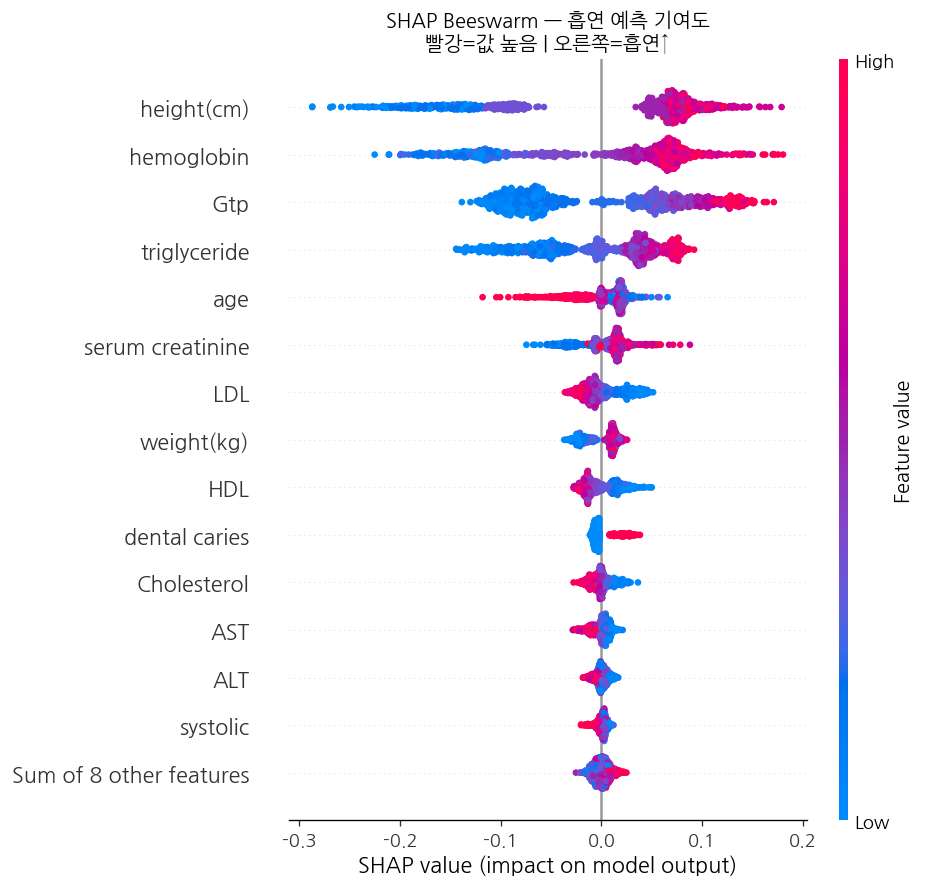

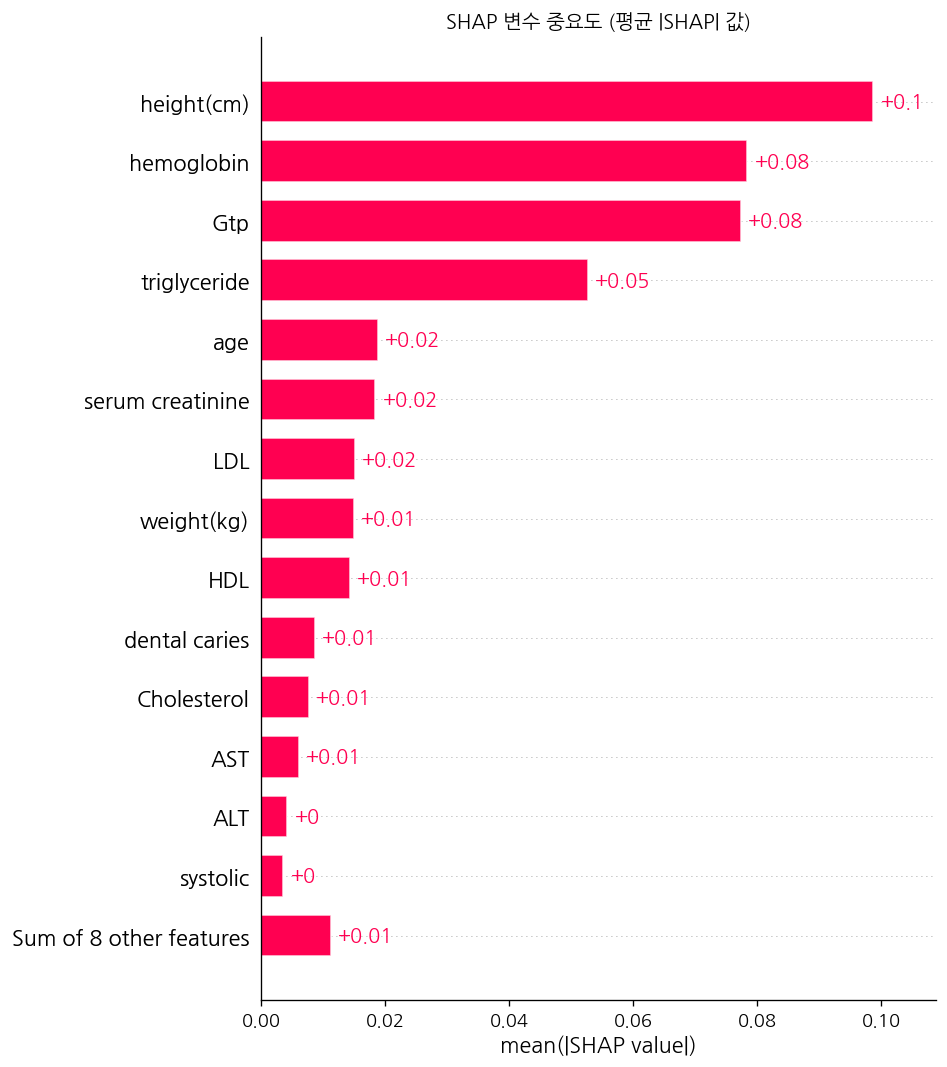

In [24]:
X_shap    = X_test.sample(n=1000, random_state=42)
explainer = shap.TreeExplainer(rf)
shap_vals = explainer(X_shap)

# RF는 다중 클래스 → 흡연(클래스 1) 슬라이싱
sv1 = shap_vals[..., 1]   # shape: (1000, n_features)

# ── Beeswarm ──────────────────────────────────────────────
shap.plots.beeswarm(sv1, max_display=15, show=False)
plt.title('SHAP Beeswarm — 흡연 예측 기여도\n빨강=값 높음 | 오른쪽=흡연↑',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar ───────────────────────────────────────────────────
shap.plots.bar(sv1, max_display=15, show=False)
plt.title('SHAP 변수 중요도 (평균 |SHAP| 값)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()



```
Cell 11-B 추가 — 통계 검정 (Mann-Whitney U + 효과크기)```



In [27]:
from scipy import stats

test_vars = ['hemoglobin', 'Gtp', 'triglyceride', 'ALT',
             'systolic', 'waist(cm)', 'Cholesterol', 'HDL']

rows = []
for var in test_vars:
    g0 = df[df[TARGET_COL] == 0][var].dropna()
    g1 = df[df[TARGET_COL] == 1][var].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')

    # 효과크기: rank-biserial correlation
    n0, n1  = len(g0), len(g1)
    r       = 1 - (2 * stat) / (n0 * n1)   # rank-biserial r

    rows.append({
        '변수'      : var,
        '비흡연자 중앙값': round(float(g0.median()), 2),
        '흡연자 중앙값' : round(float(g1.median()), 2),
        'U statistic': round(stat, 0),
        'p-value'   : p,
        '효과크기 r'  : round(abs(r), 3),
        '유의성'     : '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    })

stat_df = pd.DataFrame(rows).sort_values('효과크기 r', ascending=False)
display(stat_df)
stat_df.to_csv('stat_test.csv', index=False)
print("\n효과크기 해석: r≥0.5=large, 0.3~0.5=medium, 0.1~0.3=small")

,변수,비흡연자 중앙값,흡연자 중앙값,U statistic,p-value,효과크기 r,유의성
0,hemoglobin,14.2,15.6,1.459528e+09,0.000000e+00,0.532,***
1,Gtp,21.0,37.0,1.586412e+09,0.000000e+00,0.492,***
2,triglyceride,93.0,145.0,1.853313e+09,0.000000e+00,0.406,***
7,HDL,57.0,49.0,4.110948e+09,0.000000e+00,0.317,***
5,waist(cm),81.0,85.9,2.166233e+09,0.000000e+00,0.306,***
3,ALT,20.0,26.0,2.296856e+09,0.000000e+00,0.264,***
4,systolic,120.0,122.0,2.893018e+09,3.447705e-138,0.073,***
6,Cholesterol,198.0,195.0,3.307365e+09,1.235089e-93,0.060,***



효과크기 해석: r≥0.5=large, 0.3~0.5=medium, 0.1~0.3=small


## 📉 Cell 12 · ROC 커브 + 혼동행렬

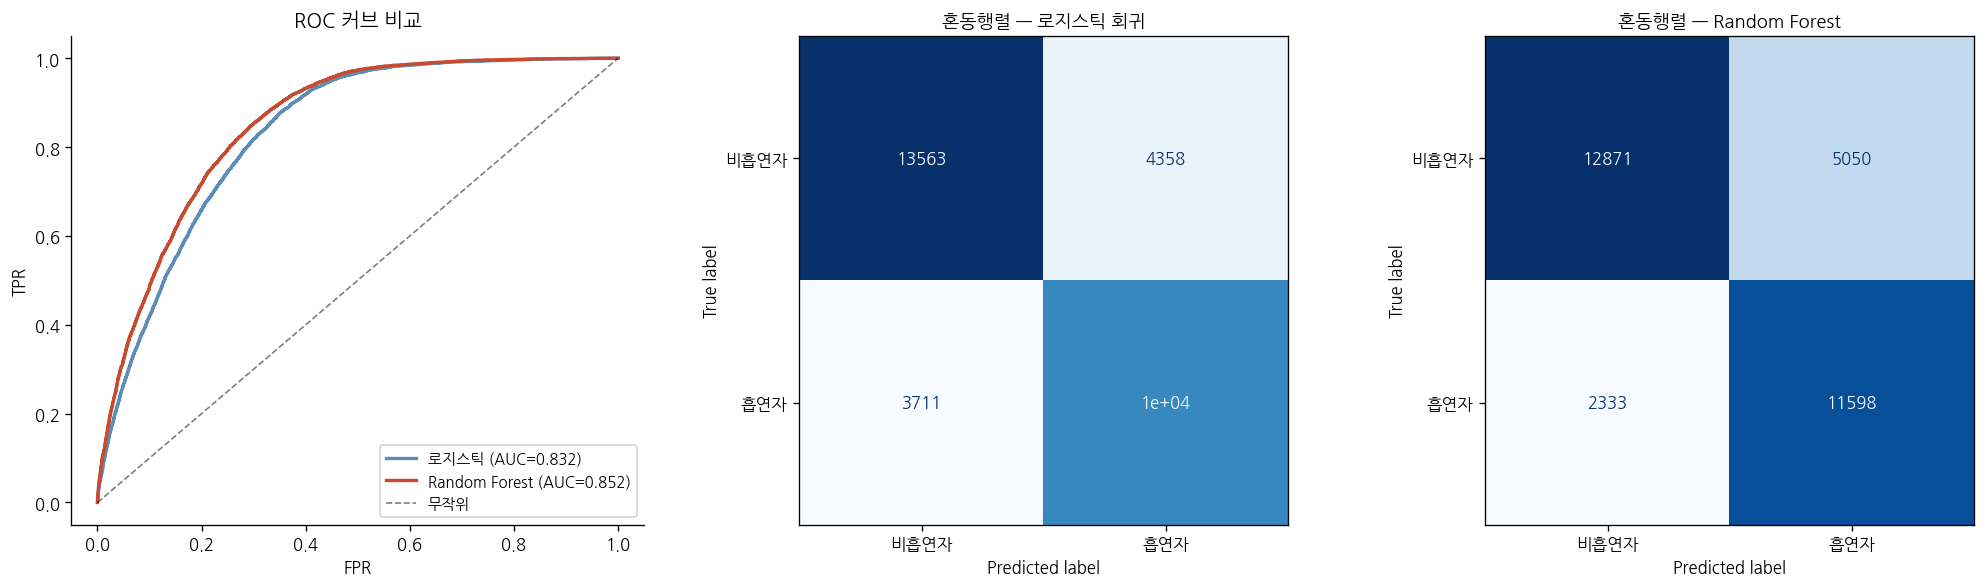

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
ax.plot(fpr_lr, tpr_lr, color='#5B8DB8', lw=2, label=f'로지스틱 (AUC={auc_lr:.3f})')
ax.plot(fpr_rf, tpr_rf, color='#C84B31', lw=2, label=f'Random Forest (AUC={auc_rf:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='무작위')
ax.set(xlabel='FPR', ylabel='TPR', title='ROC 커브 비교')
ax.legend(fontsize=9)
sns.despine(ax=ax)

for ax, pred, title in zip(
    axes[1:], [y_pred_lr, y_pred_rf], ['로지스틱 회귀', 'Random Forest']
):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['비흡연자', '흡연자'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'혼동행렬 — {title}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('roc_cm.png', bbox_inches='tight')
plt.show()

## ✅ Cell 13 · 5-Fold 교차검증 + 최종 결과 요약

In [29]:
# Cell 13 교체 전체 코드
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_lr   = cross_val_score(lr_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_rf   = cross_val_score(rf,      X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_lgbm = cross_val_score(lgbm,    X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

result = pd.DataFrame({
    '모델'         : ['로지스틱 회귀', 'Random Forest', 'LightGBM'],
    'Test AUC'     : [round(auc_lr,4), round(auc_rf,4), round(auc_lgbm,4)],
    'CV AUC (mean)': [round(cv_lr.mean(),4), round(cv_rf.mean(),4), round(cv_lgbm.mean(),4)],
    'CV AUC (std)' : [round(cv_lr.std(),4),  round(cv_rf.std(),4),  round(cv_lgbm.std(),4)],
})
print('=' * 50)
print('최종 모델 성능 요약')
print('=' * 50)
display(result)

top3 = (pd.DataFrame({'변수': FEATURE_COLS, '중요도': rf.feature_importances_})
        .sort_values('중요도', ascending=False).head(3)['변수'].tolist())
print(f"\n핵심 예측 변수 Top 3: {', '.join(top3)}")

최종 모델 성능 요약


,모델,Test AUC,CV AUC (mean),CV AUC (std)
0,로지스틱 회귀,0.8315,0.8359,0.0020
1,Random Forest,0.8520,0.8536,0.0017
2,LightGBM,0.8658,0.8683,0.0011



핵심 예측 변수 Top 3: height(cm), hemoglobin, Gtp


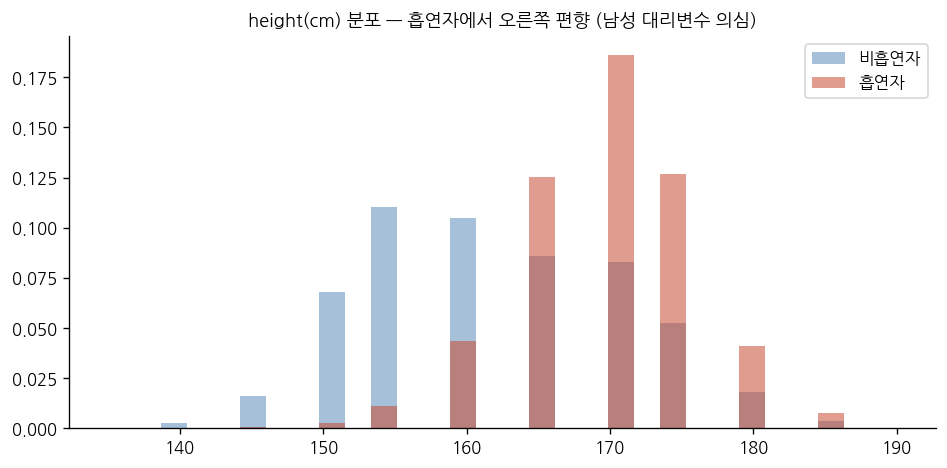

흡연자 평균 키: 169.7
비흡연자 평균 키: 161.8


In [30]:
# height 분포 → 성별 대리변수 확인
fig, ax = plt.subplots(figsize=(8, 4))
for s, color, label in [(0,'#5B8DB8','비흡연자'), (1,'#C84B31','흡연자')]:
    ax.hist(df[df[TARGET_COL]==s]['height(cm)'], bins=30,
            alpha=0.55, color=color, label=label, density=True)
ax.set_title('height(cm) 분포 — 흡연자에서 오른쪽 편향 (남성 대리변수 의심)',
             fontsize=11, fontweight='bold')
ax.legend(); sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('height_proxy.png', dpi=150, bbox_inches='tight')
plt.show()

print("흡연자 평균 키:", df[df[TARGET_COL]==1]['height(cm)'].mean().round(1))
print("비흡연자 평균 키:", df[df[TARGET_COL]==0]['height(cm)'].mean().round(1))